In [12]:
# imports

import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.manifold import TSNE

import brain_observatory_utilities.datasets.optical_physiology.data_formatting as ophys_formatting
import brain_observatory_utilities.utilities.general_utilities as utilities

from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorOphysProjectCache

In [13]:
# read data from cache
# or download if necessary

data_storage_directory = "./tmp"  # Note: this path must exist on your local drive
cache = VisualBehaviorOphysProjectCache.from_s3_cache(cache_dir=data_storage_directory)

session_table = cache.get_ophys_session_table()
experiment_table = cache.get_ophys_experiment_table()

In [22]:
# how many mice?
len(np.unique(session_table.mouse_id))

107

In [66]:
# how many sessions per mouse?

session_counts = {}

for mouse_id in np.unique(session_table.mouse_id):
    sessions_for_mouse = session_table[session_table.mouse_id == mouse_id]
    session_counts[mouse_id] = len(sessions_for_mouse)

min(session_counts.values()), max(session_counts.values())

(4, 11)

/home/alex/Dokumente/repos/CN-pr-Allen-Brain/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/home/alex/Dokumente/repos/CN-pr-Allen-Brain/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/home/alex/Dokumente/repos/CN-pr-Allen-Brain/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/home/alex/Dokume

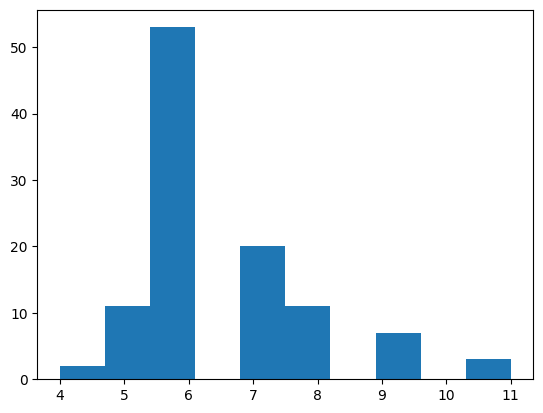

In [64]:
plt.hist(session_counts.values());

In [91]:
ophys_session_ids = np.array(session_table.index)
# there are no duplicate session ids
assert len(ophys_session_ids) == len(np.unique(ophys_session_ids))

len(ophys_session_ids)

705

In [98]:
experiments_per_session = {}

for session_id in ophys_session_ids:
    experiment_count = len(experiment_table[experiment_table.ophys_session_id == session_id])
    experiments_per_session[session_id] = experiment_count

min(experiments_per_session.values()), max(experiments_per_session.values())

(0, 8)

In [100]:
# downloading experiments or loading from cache

experiments = {}
ophys_experiment_ids = session_table.loc[ophys_session_id]['ophys_experiment_id']
for ophys_experiment_id in ophys_experiment_ids:
    experiments[ophys_experiment_id] = cache.get_behavior_ophys_experiment(ophys_experiment_id)

/home/alex/Dokumente/repos/CN-pr-Allen-Brain/.venv/lib/python3.11/site-packages/hdmf/spec/namespace.py:531: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.3.0 because version 1.5.1 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/home/alex/Dokumente/repos/CN-pr-Allen-Brain/.venv/lib/python3.11/site-packages/hdmf/spec/namespace.py:531: UserWarning: Ignoring cached namespace 'core' version 2.2.5 because version 2.5.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/home/alex/Dokumente/repos/CN-pr-Allen-Brain/.venv/lib/python3.11/site-packages/hdmf/spec/namespace.py:531: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.3.0 because version 1.5.1 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/home/alex/Dokumente/repos/CN-pr-Allen-Brain/.venv/lib/python3.11/site-packages/hdmf/spec/na